In [7]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np

In [8]:
df=pd.read_json(r"C:\Users\Bhupender Singh\Downloads\tableConvert.com_i7gwno.json")

In [9]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,,360,1,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128,360,1,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66,360,1,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120,360,1,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141,360,1,Urban,Y


In [10]:
df.drop("Loan_ID",axis=1,inplace=True)

In [11]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,,360,1,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128,360,1,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66,360,1,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120,360,1,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141,360,1,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71,360,1,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40,180,1,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253,360,1,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187,360,1,Urban,Y


In [12]:
cols=["Gender","Married","Education","Self_Employed","Property_Area","Loan_Status"]
df[cols]

,Gender,Married,Education,Self_Employed,Property_Area,Loan_Status
0,Male,No,Graduate,No,Urban,Y
1,Male,Yes,Graduate,No,Rural,N
2,Male,Yes,Graduate,Yes,Urban,Y
3,Male,Yes,Not Graduate,No,Urban,Y
4,Male,No,Graduate,No,Urban,Y
...,...,...,...,...,...,...
609,Female,No,Graduate,No,Rural,Y
610,Male,Yes,Graduate,No,Rural,Y
611,Male,Yes,Graduate,No,Urban,Y
612,Male,Yes,Graduate,No,Urban,Y


In [13]:
df["Dependents"] = df["Dependents"].replace("3+", 3)
df["Dependents"] = pd.to_numeric(df["Dependents"], errors="coerce")


In [14]:
from sklearn.preprocessing import LabelEncoder

In [15]:
le=LabelEncoder()

In [16]:
for col in cols:
    df[col] = le.fit_transform(df[col])

In [17]:
df[col]

0      1
1      0
2      1
3      1
4      1
      ..
609    1
610    1
611    1
612    1
613    0
Name: Loan_Status, Length: 614, dtype: int32

In [18]:
std_cols=["ApplicantIncome","CoapplicantIncome","LoanAmount","Loan_Amount_Term","Credit_History"]
df[std_cols]

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,5849,0.0,,360,1
1,4583,1508.0,128,360,1
2,3000,0.0,66,360,1
3,2583,2358.0,120,360,1
4,6000,0.0,141,360,1
...,...,...,...,...,...
609,2900,0.0,71,360,1
610,4106,0.0,40,180,1
611,8072,240.0,253,360,1
612,7583,0.0,187,360,1


In [19]:
for col in std_cols:
    print(col, df[col].dtype)
    print(df[col].unique()[:10])


ApplicantIncome int64
[ 5849  4583  3000  2583  6000  5417  2333  3036  4006 12841]
CoapplicantIncome float64
[    0.  1508.  2358.  4196.  1516.  2504.  1526. 10968.   700.  1840.]
LoanAmount object
['' '128' '66' '120' '141' '267' '95' '158' '168' '349']
Loan_Amount_Term object
['360' '120' '240' '' '180' '60' '300' '480' '36' '84']
Credit_History object
['1' '0' '']


In [20]:
num_cols = X.select_dtypes(include=["int64","float64"]).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())


NameError: name 'X' is not defined

In [21]:
for col in std_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


In [22]:
for col in std_cols:
    df[col].fillna(df[col].median(), inplace=True)


C:\Users\Bhupender Singh\AppData\Local\Temp\ipykernel_16056\3115218068.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
sc=StandardScaler()

In [25]:
df[std_cols] = sc.fit_transform(df[std_cols])

In [26]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,2,1,0.0,0,1,0.072991,-0.554487,-0.211241,0.273231,0.411733,2,1
1,2,2,1.0,0,1,-0.134412,-0.038732,-0.211241,0.273231,0.411733,0,0
2,2,2,0.0,0,2,-0.393747,-0.554487,-0.948996,0.273231,0.411733,2,1
3,2,2,0.0,1,1,-0.462062,0.251980,-0.306435,0.273231,0.411733,2,1
4,2,1,0.0,0,1,0.097728,-0.554487,-0.056551,0.273231,0.411733,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
609,1,1,0.0,0,1,-0.410130,-0.554487,-0.889500,0.273231,0.411733,0,1
610,2,2,3.0,0,1,-0.212557,-0.554487,-1.258378,-2.522836,0.411733,0,1
611,2,2,1.0,0,1,0.437174,-0.472404,1.276168,0.273231,0.411733,2,1
612,2,2,2.0,0,1,0.357064,-0.554487,0.490816,0.273231,0.411733,2,1


In [27]:
df.isnull().sum()


Gender                0
Married               0
Dependents           15
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

<Axes: >

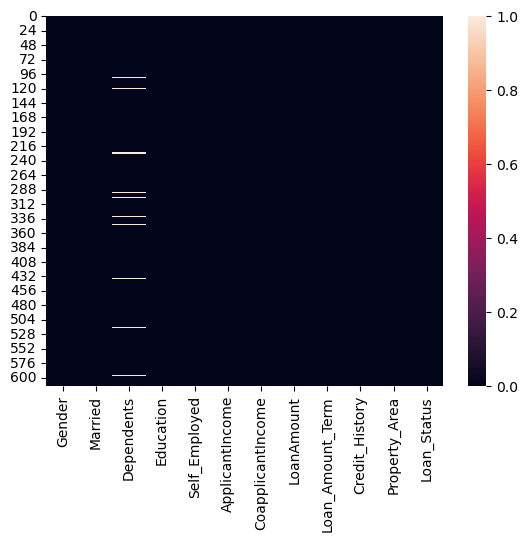

In [28]:
sns.heatmap(df.isnull())

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    int32  
 1   Married            614 non-null    int32  
 2   Dependents         599 non-null    float64
 3   Education          614 non-null    int32  
 4   Self_Employed      614 non-null    int32  
 5   ApplicantIncome    614 non-null    float64
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    int32  
 11  Loan_Status        614 non-null    int32  
dtypes: float64(6), int32(6)
memory usage: 43.3 KB


In [30]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]


In [31]:
print(X.shape, y.shape)


(614, 11) (614,)


In [32]:
# Numeric
num_cols = X.select_dtypes(include=["int64","float64"]).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

# Categorical (just in case)
cat_cols = X.select_dtypes(include=["object"]).columns
if len(cat_cols) > 0:
    X[cat_cols] = X[cat_cols].fillna(X[cat_cols].mode().iloc[0])


In [33]:
print(X.isna().sum())


Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64


In [34]:
from sklearn.linear_model import LogisticRegression
 

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)



In [36]:
print(X.shape)
print(y.shape)


(614, 11)
(614,)


In [37]:

model = LogisticRegression(max_iter=100)
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [38]:
y_pred = model.predict(X_test)


In [39]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.7727272727272727


In [40]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[21 33]
 [ 2 98]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.39      0.55        54
           1       0.75      0.98      0.85       100

    accuracy                           0.77       154
   macro avg       0.83      0.68      0.70       154
weighted avg       0.81      0.77      0.74       154



In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)


MSE : 0.22727272727272727
RMSE: 0.4767312946227962
MAE : 0.22727272727272727


In [45]:

from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Create SVC model
svc_model = SVC(kernel='linear', random_state=42)  # linear, rbf, poly are options

# Train
svc_model.fit(X_train, y_train)

# Predict
y_pred = svc_model.predict(X_test)

# Evaluate
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy :", accuracy_score(y_test, y_pred))


Confusion Matrix:
 [[21 33]
 [ 2 98]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.39      0.55        54
           1       0.75      0.98      0.85       100

    accuracy                           0.77       154
   macro avg       0.83      0.68      0.70       154
weighted avg       0.81      0.77      0.74       154

Accuracy : 0.7727272727272727


In [47]:
from sklearn.neighbors import KNeighborsClassifier

# Create KNN model (you can start with k=5)
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train
knn_model.fit(X_train, y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [48]:
y_pred = knn_model.predict(X_test)


In [49]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("Accuracy :", accuracy_score(y_test, y_pred))


Confusion Matrix:
 [[22 32]
 [ 5 95]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.41      0.54        54
           1       0.75      0.95      0.84       100

    accuracy                           0.76       154
   macro avg       0.78      0.68      0.69       154
weighted avg       0.77      0.76      0.73       154

Accuracy : 0.7597402597402597


In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Create Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,       # Number of trees
    random_state=42,
    class_weight='balanced' # Helps with imbalanced classes
)

# Train
rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [51]:
y_pred = rf_model.predict(X_test)


In [52]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("Accuracy :", accuracy_score(y_test, y_pred))


Confusion Matrix:
 [[22 32]
 [ 5 95]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.41      0.54        54
           1       0.75      0.95      0.84       100

    accuracy                           0.76       154
   macro avg       0.78      0.68      0.69       154
weighted avg       0.77      0.76      0.73       154

Accuracy : 0.7597402597402597
